# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [15]:
df = pd.read_csv('/kaggle/input/datasets/laotse/credit-risk-dataset/credit_risk_dataset.csv')

print('Shape:', df.shape)
df.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [16]:
# Info dataset
df.info()

print()
# Statistik deskriptif
print(df.describe())

print()
# Missing values
print('Missing values:')
print(df.isnull().sum())

print()
# Duplikat
print('Jumlah duplikat:', df.duplicated().sum())

print()
# Distribusi target
print('Distribusi target:')
print(df['loan_status'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB

         person_age  person_in

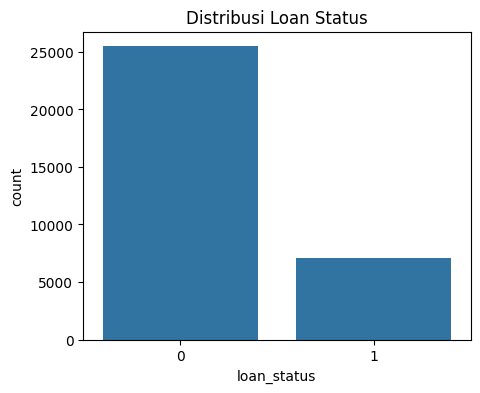

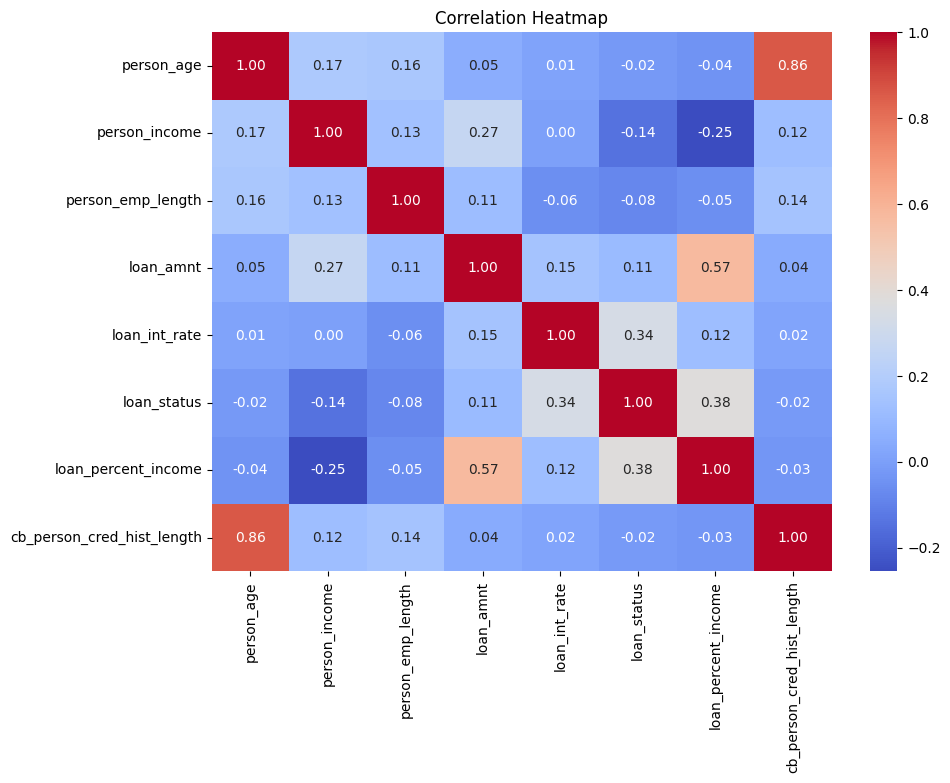

In [17]:
# Distribusi target
plt.figure(figsize=(5, 4))
sns.countplot(x='loan_status', data=df)
plt.title('Distribusi Loan Status')
plt.show()

# Korelasi heatmap (numerik)
plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [18]:
# 1. Handle missing values dengan median
imputer = SimpleImputer(strategy='median')
df['person_emp_length'] = imputer.fit_transform(df[['person_emp_length']])
df['loan_int_rate'] = imputer.fit_transform(df[['loan_int_rate']])

print('Missing values setelah impute:')
print(df.isnull().sum())

Missing values setelah impute:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [19]:
# 2. Handle duplikat
df = df.drop_duplicates()
print('Setelah drop duplikat:', df.shape)

Setelah drop duplikat: (32416, 12)


In [20]:
# 3. Encoding kategorikal
le = LabelEncoder()
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,3,123.0,4,3,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4


In [21]:
# 4. Hapus outlier
df = df[df['person_age'] < 100]
df = df[df['person_emp_length'] < 60]
print('Setelah hapus outlier:', df.shape)

Setelah hapus outlier: (32409, 12)


In [22]:
# 5. Split fitur dan target
X = df.drop('loan_status', axis=1)
y = df['loan_status']

print('Shape X:', X.shape)
print('Shape y:', y.shape)

Shape X: (32409, 11)
Shape y: (32409,)


In [23]:
# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (25927, 11)
Test size: (6482, 11)


In [24]:
# 7. SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Distribusi setelah SMOTE (train):')
print(pd.Series(y_train_res).value_counts())

Distribusi setelah SMOTE (train):
loan_status
0    20257
1    20257
Name: count, dtype: int64


In [25]:
# 8. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print('Shape X_train final:', X_train_scaled.shape)
print('Shape X_test final:', X_test_scaled.shape)

Shape X_train final: (40514, 11)
Shape X_test final: (6482, 11)


In [26]:
# 9. Simpan hasil preprocessing
train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
train_df['loan_status'] = y_train_res.values

test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
test_df['loan_status'] = y_test.values

train_df.to_csv('credit_risk_train.csv', index=False)
test_df.to_csv('credit_risk_test.csv', index=False)

print('Train dataset tersimpan! Shape:', train_df.shape)
print('Test dataset tersimpan! Shape:', test_df.shape)
train_df.head()

Train dataset tersimpan! Shape: (40514, 12)
Test dataset tersimpan! Shape: (6482, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,1.658931,0.521714,-1.335548,3.911906,-0.185798,-0.329133,-0.002575,-0.554673,-0.636598,-0.42272,2.754924,0
1,-0.410569,-0.203647,0.859073,0.670651,-0.796492,2.213518,-0.229849,1.298545,-0.224195,-0.42272,-0.408979,0
2,-0.238110,0.625337,-1.335548,-0.949977,1.035591,-0.329133,1.512581,-0.230117,0.188208,-0.42272,-0.672637,0
3,2.348764,0.598643,0.859073,-0.679872,1.646285,-0.329133,0.906518,-0.243099,-0.141714,-0.42272,2.491266,0
4,1.314014,-0.431617,0.859073,-0.679872,0.424896,0.518417,-0.002575,0.474171,0.518130,-0.42272,0.118339,1
